# Proyecto I parte II

#Análisis y Predicción de Ventas en una Tienda de Retail

In [1]:
import pandas as pd
df = pd.read_csv('/content/retail_sales_dataset.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [3]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [4]:
df.shape

(1000, 9)

In [5]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [6]:
df.tail(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


. Inspección de los Datos

In [7]:
#Inspecciona los tipos de datos de cada columna utilizando el atributo dtypes.
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [8]:
#Cuenta los valores únicos en la columna Producto utilizando el método value_counts().
df['Product Category'].value_counts()

,count
Product Category,
Clothing,351
Electronics,342
Beauty,307


In [9]:
#Muestra todos los valores únicos en la columna Tienda utilizando el método unique().
print("Este data set no tiene una categoría 'Tienda'")

Este data set no tiene una categoría 'Tienda'


- Filtrado de Datos

In [10]:
#Filtra el DataFrame para mostrar solo las filas donde las ventas (Ventas) sean mayores a 50.
df[df['Total Amount'] > 50]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
...,...,...,...,...,...,...,...,...,...
993,994,2023-12-18,CUST994,Female,51,Beauty,2,500,1000
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [11]:
#Filtra el DataFrame para mostrar solo las filas donde el precio (Precio) sea menor a 0.5.
df[df['Price per Unit'] < 50]

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
11,12,2023-10-30,CUST012,Male,35,Beauty,3,25,75
...,...,...,...,...,...,...,...,...,...
991,992,2023-08-21,CUST992,Female,57,Electronics,2,30,60
994,995,2023-04-30,CUST995,Female,41,Clothing,1,30,30
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100


en el codigo anterior pedia datos para un precio menor a 0.5 pero eso no filtró nada entonces decidí cambiar el rango de precio a 50

In [12]:
#Utilizando el método query(), filtra el DataFrame para mostrar las filas donde el producto sea Manzanas y las ventas sean mayores a 30.
print("Ninguna categoría contiene el producto manzana'")


Ninguna categoría contiene el producto manzana'


-Slicing de Datos

In [13]:
#Selecciona y muestra solo las columnas Producto y Ventas del DataFrame.
df[['Product Category', 'Quantity']]

,Product Category,Quantity
0,Beauty,3
1,Clothing,2
2,Electronics,1
3,Clothing,1
4,Beauty,2
...,...,...
995,Clothing,1
996,Beauty,3
997,Beauty,4
998,Electronics,3


In [14]:
#Utilizando loc[], selecciona y muestra las filas de la 5 a la 10 (inclusive) y las columnas Producto y Tienda.

df.loc [5:10, ['Product Category', 'Gender']] #No hay tienda

,Product Category,Gender
5,Beauty,Female
6,Clothing,Male
7,Electronics,Male
8,Electronics,Male
9,Clothing,Female
10,Clothing,Male


Se reemplaza "Tienda" por "Genero" debido a que el primero no existe

In [15]:
#Utilizando iloc[], selecciona y muestra las primeras 5 filas y las primeras 3 columnas del DataFrame.
df.iloc[0:5, 0:3]

,Transaction ID,Date,Customer ID
0,1,2023-11-24,CUST001
1,2,2023-02-27,CUST002
2,3,2023-01-13,CUST003
3,4,2023-05-21,CUST004
4,5,2023-05-06,CUST005


================================================================================

#Proyecto I parte III

================================================================================

- Transformación de Datos

In [16]:
#Nueva columna: precio promedio real pagado por unidad
df['ganancia_por_unidad'] = df['Total Amount'] / df['Quantity']
print("Ganancia por unidad: ")
print(df[['Quantity', 'Price per Unit', 'Total Amount', 'ganancia_por_unidad']])

Ganancia por unidad: 
     Quantity  Price per Unit  Total Amount  ganancia_por_unidad
0           3              50           150                 50.0
1           2             500          1000                500.0
2           1              30            30                 30.0
3           1             500           500                500.0
4           2              50           100                 50.0
..        ...             ...           ...                  ...
995         1              50            50                 50.0
996         3              30            90                 30.0
997         4              25           100                 25.0
998         3              50           150                 50.0
999         4              30           120                 30.0

[1000 rows x 4 columns]


- Normalización Min-Max del total amount

In [17]:
min_val = df['Total Amount'].min()
max_val = df['Total Amount'].max()

df['total_amount_norm'] = (df['Total Amount'] - min_val) / (max_val - min_val)

print("Normalizacion:")
print(df[['Total Amount', 'total_amount_norm']])

Normalizacion:
     Total Amount  total_amount_norm
0             150           0.063291
1            1000           0.493671
2              30           0.002532
3             500           0.240506
4             100           0.037975
..            ...                ...
995            50           0.012658
996            90           0.032911
997           100           0.037975
998           150           0.063291
999           120           0.048101

[1000 rows x 2 columns]


In [18]:
#Clasificación ventas en Alta, Media y Baja
p33 = df['Total Amount'].quantile(0.33)
p66 = df['Total Amount'].quantile(0.66)

def clasificar_venta(monto):
  if monto <= p33:
    return 'Baja'
  elif monto <= p66:
    return 'Media'
  else:
    return 'Alta'

df['Categoria de ventas'] = df['Total Amount'].apply(clasificar_venta)

print(f"Cortes: Baja ≤ {p33}, Media ≤ {p66}, Alta >{p66}")
print("\nDistribucion:")
print(df['Categoria de ventas'].value_counts())

Cortes: Baja ≤ 90.0, Media ≤ 500.0, Alta >500.0

Distribucion:
Categoria de ventas
Media    352
Baja     349
Alta     299
Name: count, dtype: int64


Grupos balanceados de acuerdo al corte de los percentiles

- Agrupación y Agregación

In [19]:
#Extracción de mes en la columna date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

#Agrupación por categoría de producto y genero
grupo1 = df.groupby(['Product Category', 'Gender']) ['Total Amount'].agg(
    total = 'sum',
    promedio = 'mean',
    cantidad = 'count',
    minimo = 'min',
    maximo = 'max',
    std = 'std',
    varianza = 'var'
).round(2)

print("Ventas por categoría y Género:")
print(grupo1)


Ventas por categoría y Género:
                         total  promedio  cantidad  minimo  maximo     std  \
Product Category Gender                                                      
Beauty           Female  74830    450.78       166      25    2000  538.74   
                 Male    68685    487.13       141      25    2000  592.90   
Clothing         Female  81275    467.10       174      25    2000  577.02   
                 Male    74305    419.80       177      25    2000  524.12   
Electronics      Female  76735    451.38       170      25    2000  548.64   
                 Male    80170    466.10       172      25    2000  587.13   

                          varianza  
Product Category Gender             
Beauty           Female  290235.44  
                 Male    351530.08  
Clothing         Female  332948.03  
                 Male    274697.83  
Electronics      Female  301010.95  
                 Male    344721.29  


como era de esperar, la categoria mas alta es de ropa para el genero de las mujeres mientras que el mas alto para los hombres es el de electronics y la varianza es muy alta en todas las categorias lo que significa que las ventas son muy dispersas.

- Análisis Personalizado con apply

In [20]:
#Cuanto se desvia cada venta respecto a la media de su categoria de producto
def desviacion_respecto_media(grupo):
  return grupo - grupo.mean()

df['desviacion-vs-media'] = df.groupby('Product Category')['Total Amount'].apply(desviacion_respecto_media).reset_index(level=0, drop=True)

print("Desviación de cada venta respecto a la media de su categoría:")
print(df[['Product Category', 'Total Amount', 'desviacion-vs-media']].head(10))

Desviación de cada venta respecto a la media de su categoría:
  Product Category  Total Amount  desviacion-vs-media
0           Beauty           150          -317.475570
1         Clothing          1000           556.752137
2      Electronics            30          -428.786550
3         Clothing           500            56.752137
4           Beauty           100          -367.475570
5           Beauty            30          -437.475570
6         Clothing            50          -393.247863
7      Electronics           100          -358.786550
8      Electronics           600           141.213450
9         Clothing           200          -243.247863


ventas negativas estan por debajo de del promedio de ventas de su categoria, pero es normal debido a lo disperso que es el comportamiento de las ventas.

================================================================================

#Proyecto I parte IV

================================================================================

- Histogramas de variables numericas clave

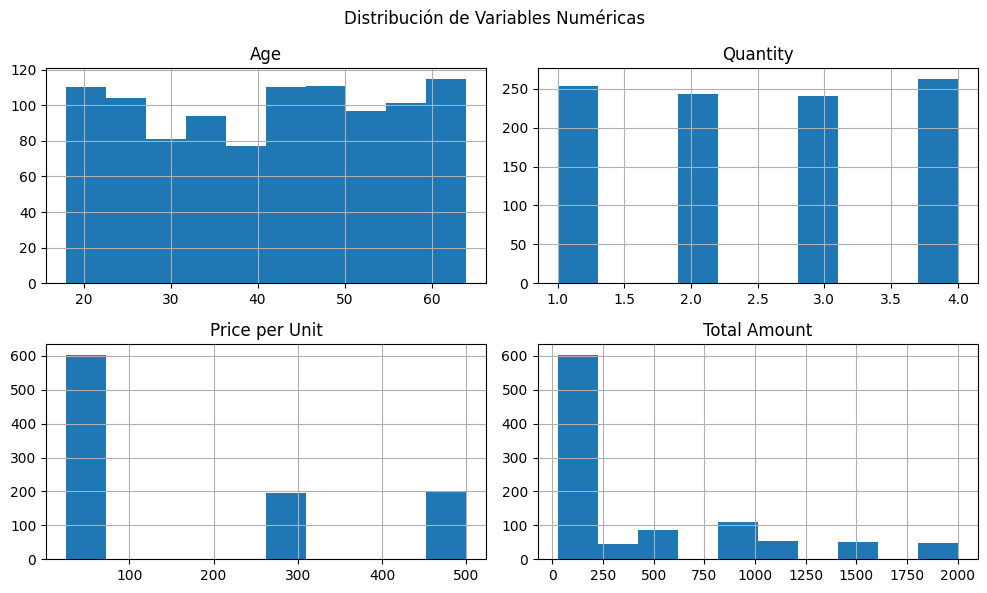

In [21]:
import matplotlib.pyplot as plt

df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].hist(bins=10, figsize=(10,6))
plt.suptitle("Distribución de Variables Numéricas")
plt.tight_layout()
plt.show()

Age: aprox entre los 20 y 60 años la distribucion de ventas es uniforme
Quantity: la mayoria compra entre 1 y 4 unidades
Price per unit: la mayor cantidad de productos cuesta alrededor de 100 y unos pocos 300 y 500 aprox
Total amount: la mayor cantidad de ventas son de 250

- Boxplot

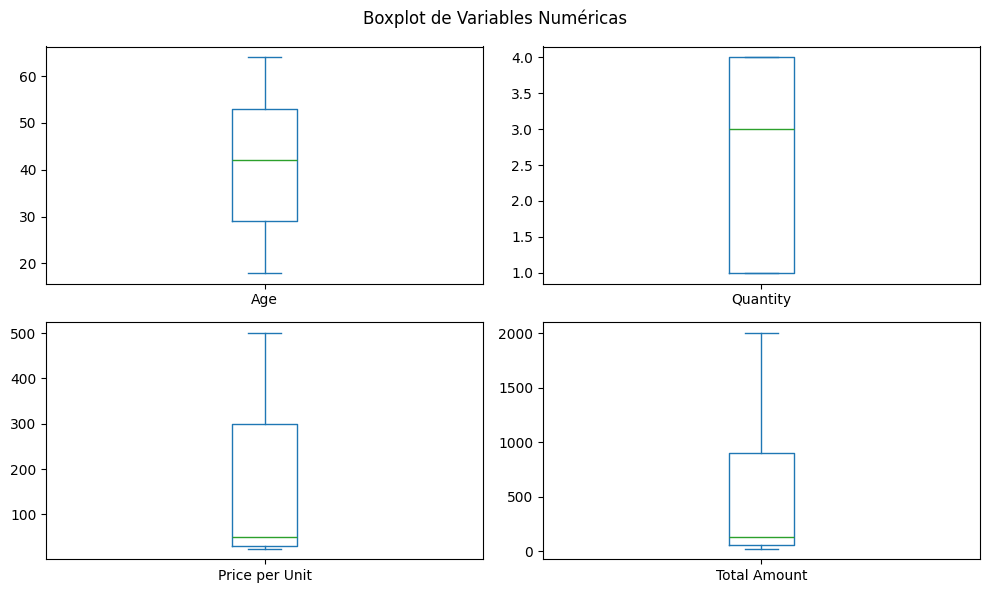

In [22]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].plot(
    kind='box', figsize=(10,6), subplots=True, layout=(2,2)
    )
plt.suptitle("Boxplot de Variables Numéricas")
plt.tight_layout()
plt.show(
)

no se observan valores atipicos (layouts)

- Gráfico de lineas

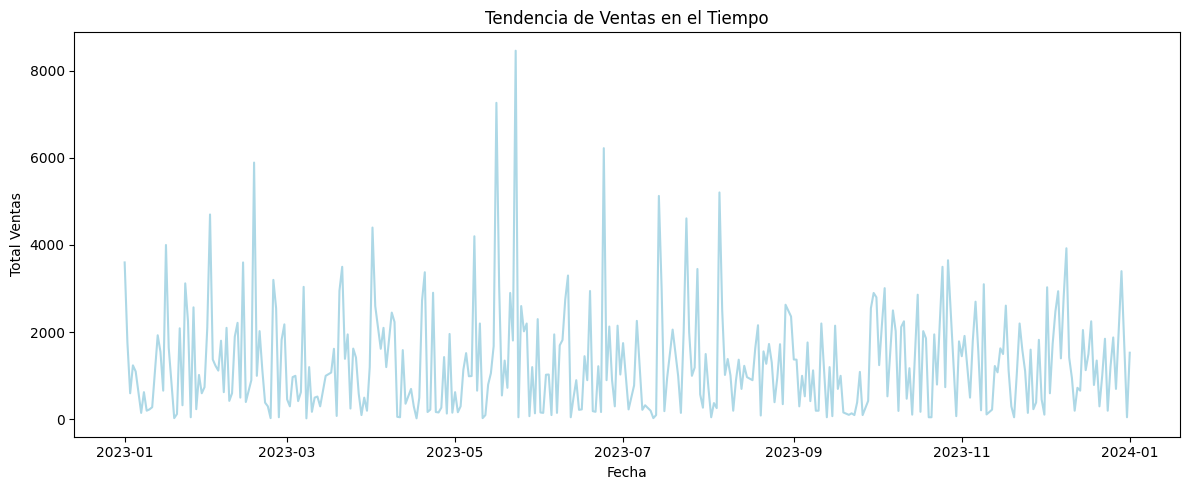

In [23]:
df['Date'] = pd.to_datetime(df['Date'])
ventas_por_fecha = df.groupby('Date')['Total Amount'].sum()
plt.figure(figsize=(12,5))
plt.plot(ventas_por_fecha.index, ventas_por_fecha.values, color='lightblue')
plt.title('Tendencia de Ventas en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Total Ventas')
plt.tight_layout()
plt.show()

Las ventas diarias son irregulares por lo tanto no se marca una tendencia

-Gráfico de dispersión- relación entre Age y Total Amount

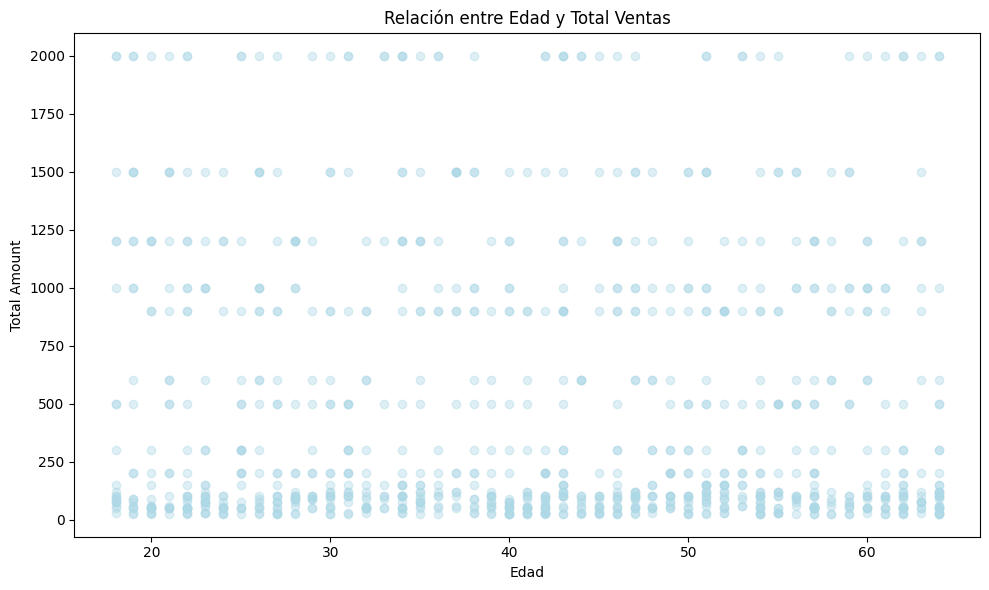

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'], df['Total Amount'], alpha=0.4, color='lightblue')
plt.title('Relación entre Edad y Total Ventas')
plt.xlabel('Edad')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

los valores se concentran en lineas horizontales ya que los precios por unidad tiene valores fijos, esto confirma que la edad del cliente no influye en cuanto gasta

================================================================================

#Proyecto I parte V

================================================================================

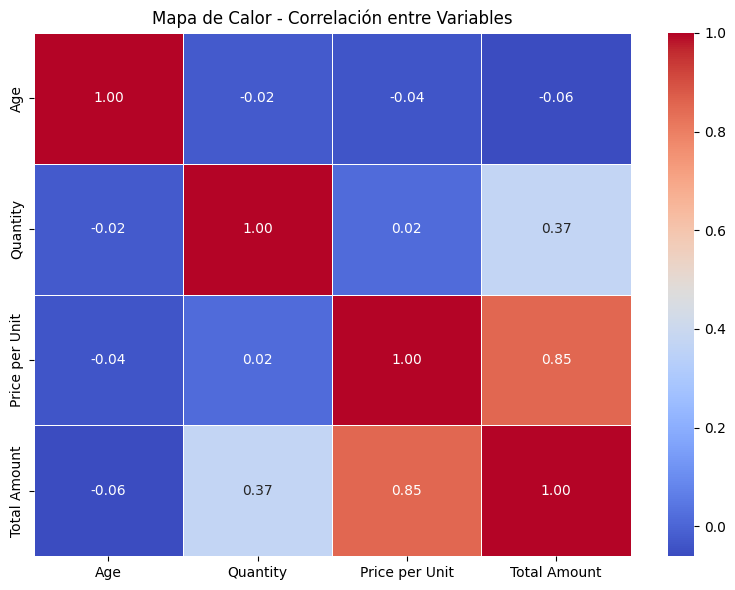

In [26]:
import seaborn as sns

#Analisis de correlación entre variables numéricas
correlacion = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Mapa de Calor - Correlación entre Variables")
plt.tight_layout()
plt.show()

la correlacion es alta entre las variable Price por Unit y Total Amount, lo que tiene sentido.

Esta parte la hice con ayuda de IA porque ya tenia el cerebro frito.

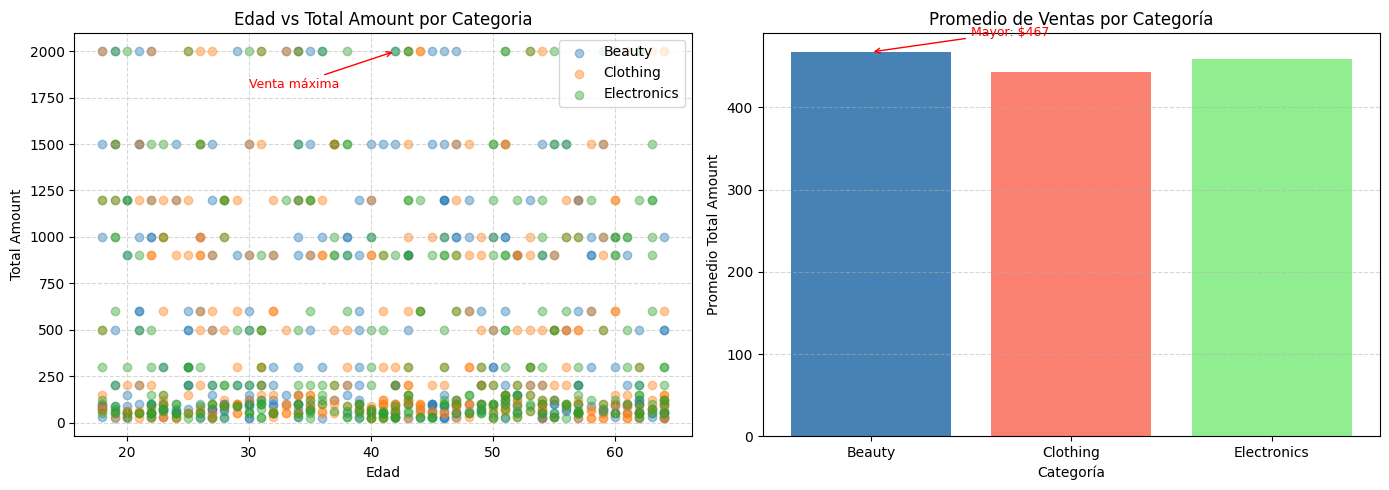

In [42]:
#Subplots comparando variables clave con cuadricula, leyenda y anotaciones
fig, axes = plt.subplots(1,2, figsize=(14,5))

#1: Total amount por product category
for category in df['Product Category'].unique():
  subset = df[df['Product Category'] == category]
  axes[0].scatter(subset['Age'], subset['Total Amount'], label=category, alpha=0.4)

axes[0].set_title("Edad vs Total Amount por Categoria")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Total Amount")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

#Anotacion con flecha en el valor maximo
max_idx = df['Total Amount'].idxmax()
axes[0].annotate('Venta máxima',
    xy=(df.loc[max_idx, 'Age'], df.loc[max_idx, 'Total Amount']),
    xytext=(30, 1800),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9)

# Subplot 2: Promedio de Total Amount por categoría
promedios = df.groupby('Product Category')['Total Amount'].mean()
axes[1].bar(promedios.index, promedios.values, color=['steelblue', 'salmon', 'lightgreen'])
axes[1].set_title("Promedio de Ventas por Categoría")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Promedio Total Amount")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Anotación en la barra más alta
max_cat = promedios.idxmax()
axes[1].annotate(f'Mayor: ${promedios[max_cat]:.0f}',
    xy=(max_cat, promedios[max_cat]),
    xytext=(0.5, promedios[max_cat] + 20),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9)

plt.tight_layout()
plt.show()



Lo que se puede leer:

Scatter izquierdo: las 3 categorías (Beauty, Clothing, Electronics) se distribuyen de forma muy similar en todas las edades — sin diferencias por edad
Barras derecho: los promedios de venta son muy similares entre las 3 categorías (~$450), con Beauty ligeramente más alto — la flecha roja lo marca